# 02 — بناء FP-Tree يدوياً خطوة بخطوة

هذا مثال **تعليمي حتمي** من ست معاملات صغيرة، وليس نتيجة من UCI Online Retail. يشرح البنية الداخلية لخوارزمية FP-Growth من المبادئ الأولى، ولا يستدعي `mlxtend` لاستخراج النتيجة اليدوية.

## لماذا طُورت FP-Growth؟

تولد Apriori مرشحين مستوى بعد مستوى ثم تمسح البيانات لاختبار دعمهم. عند انخفاض Minimum Support أو اتساع عدد المنتجات قد يكبر فضاء المرشحين بشدة. تضغط FP-Growth المعاملات في **FP-Tree** تشترك فيها البدايات المتشابهة، ثم تستخرج الأنماط من Conditional Pattern Bases من دون توليد المرشحين بالطريقة نفسها.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import FileLink, Image, display

from src.data.paths import PROJECT_ROOT, project_path
from src.mining.fp_tree_educational import FPTree, build_educational_tree
from src.mining.fp_tree_steps import generate_educational_outputs

assert Path.cwd().resolve() == PROJECT_ROOT
assert ".venv" in sys.executable
generation_summary = generate_educational_outputs(minimum_support_count=3)
generation_summary

{'minimum_support_count': 3,
 'transaction_count': 6,
 'frequent_itemset_count': 6,
 'step_figure_count': 6,
 'interactive_path': 'outputs\\interactive\\manual_fp_tree_steps.html'}

## المعاملات التعليمية وحساب التكرار

In [2]:
transactions = pd.read_csv(project_path("outputs", "tables", "manual_fp_tree_transactions.csv"))
frequencies = pd.read_csv(project_path("outputs", "tables", "manual_fp_tree_item_frequencies.csv"))
display(transactions)
display(frequencies)

,transaction_id,items
0,T1,Bread | Milk | Butter
1,T2,Bread | Milk
2,T3,Bread | Butter
3,T4,Milk | Butter
4,T5,Bread | Milk | Eggs
5,T6,Bread | Milk | Butter | Coffee


,item,support_count,is_frequent,global_order
0,Bread,5,True,1.0
1,Milk,5,True,2.0
2,Butter,4,True,3.0
3,Coffee,1,False,NaN
4,Eggs,1,False,NaN


Minimum Support العددي هو 3 من 6 معاملات. لذلك تبقى Bread وMilk وButter، بينما تُحذف Eggs وCoffee. الترتيب العالمي حتمي: الدعم تنازلياً ثم الاسم أبجدياً لكسر التعادل، أي Bread ثم Milk ثم Butter.

## إدخال المعاملات وإعادة استخدام Shared Prefix

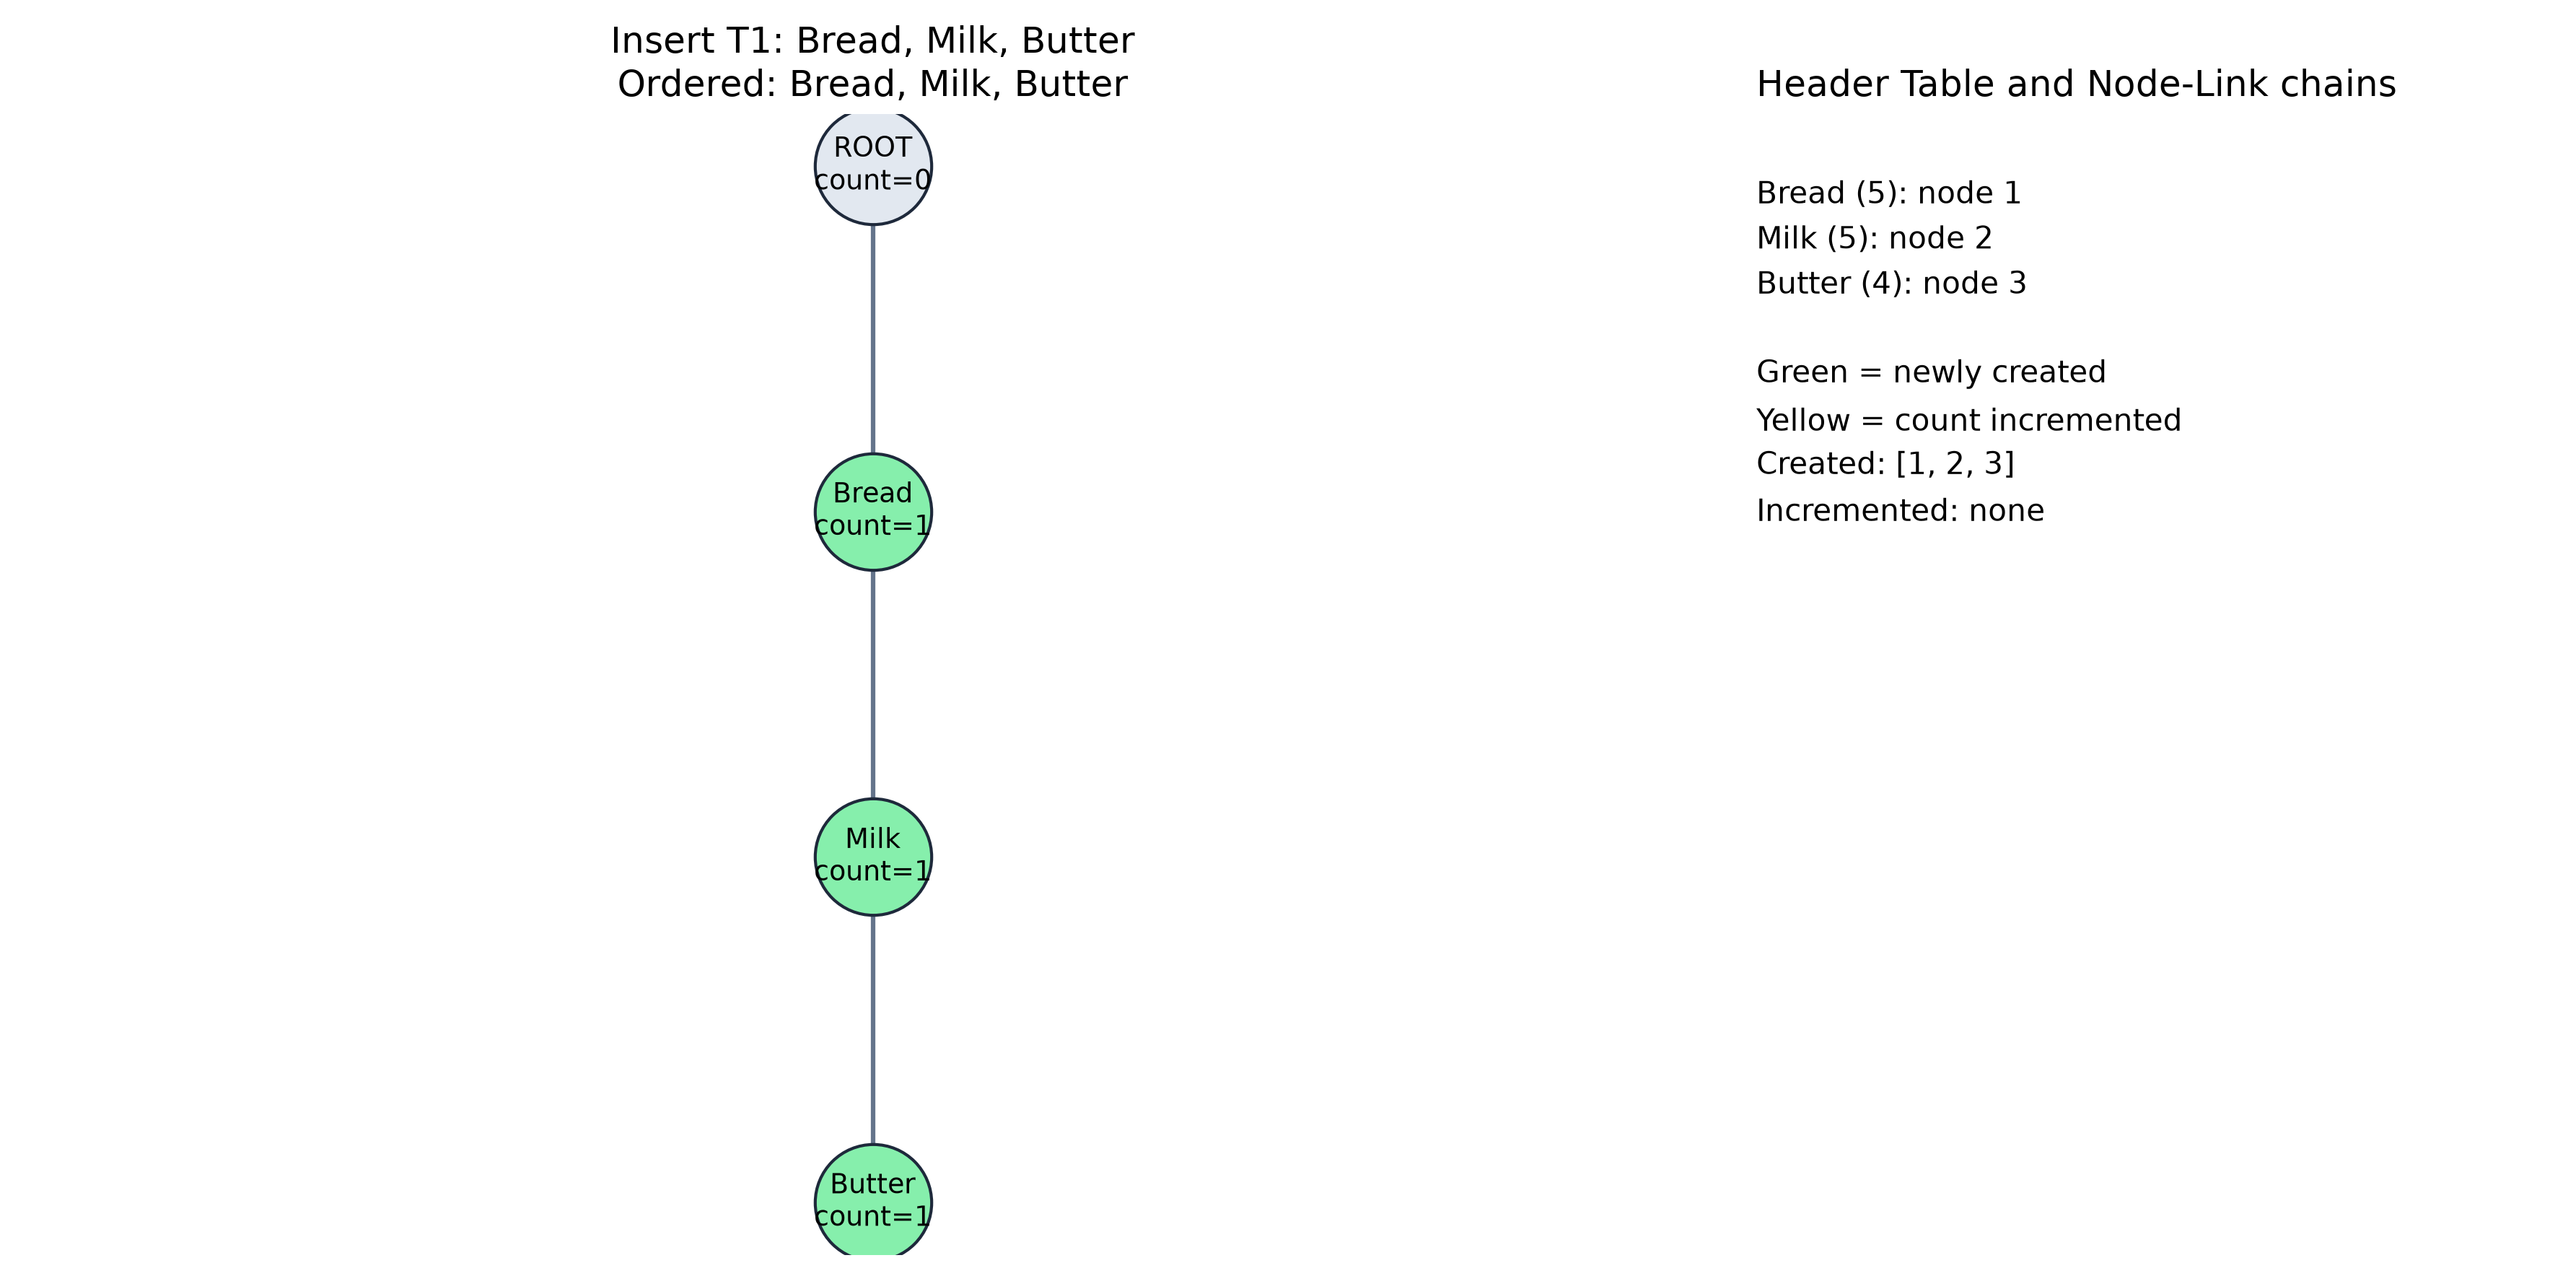

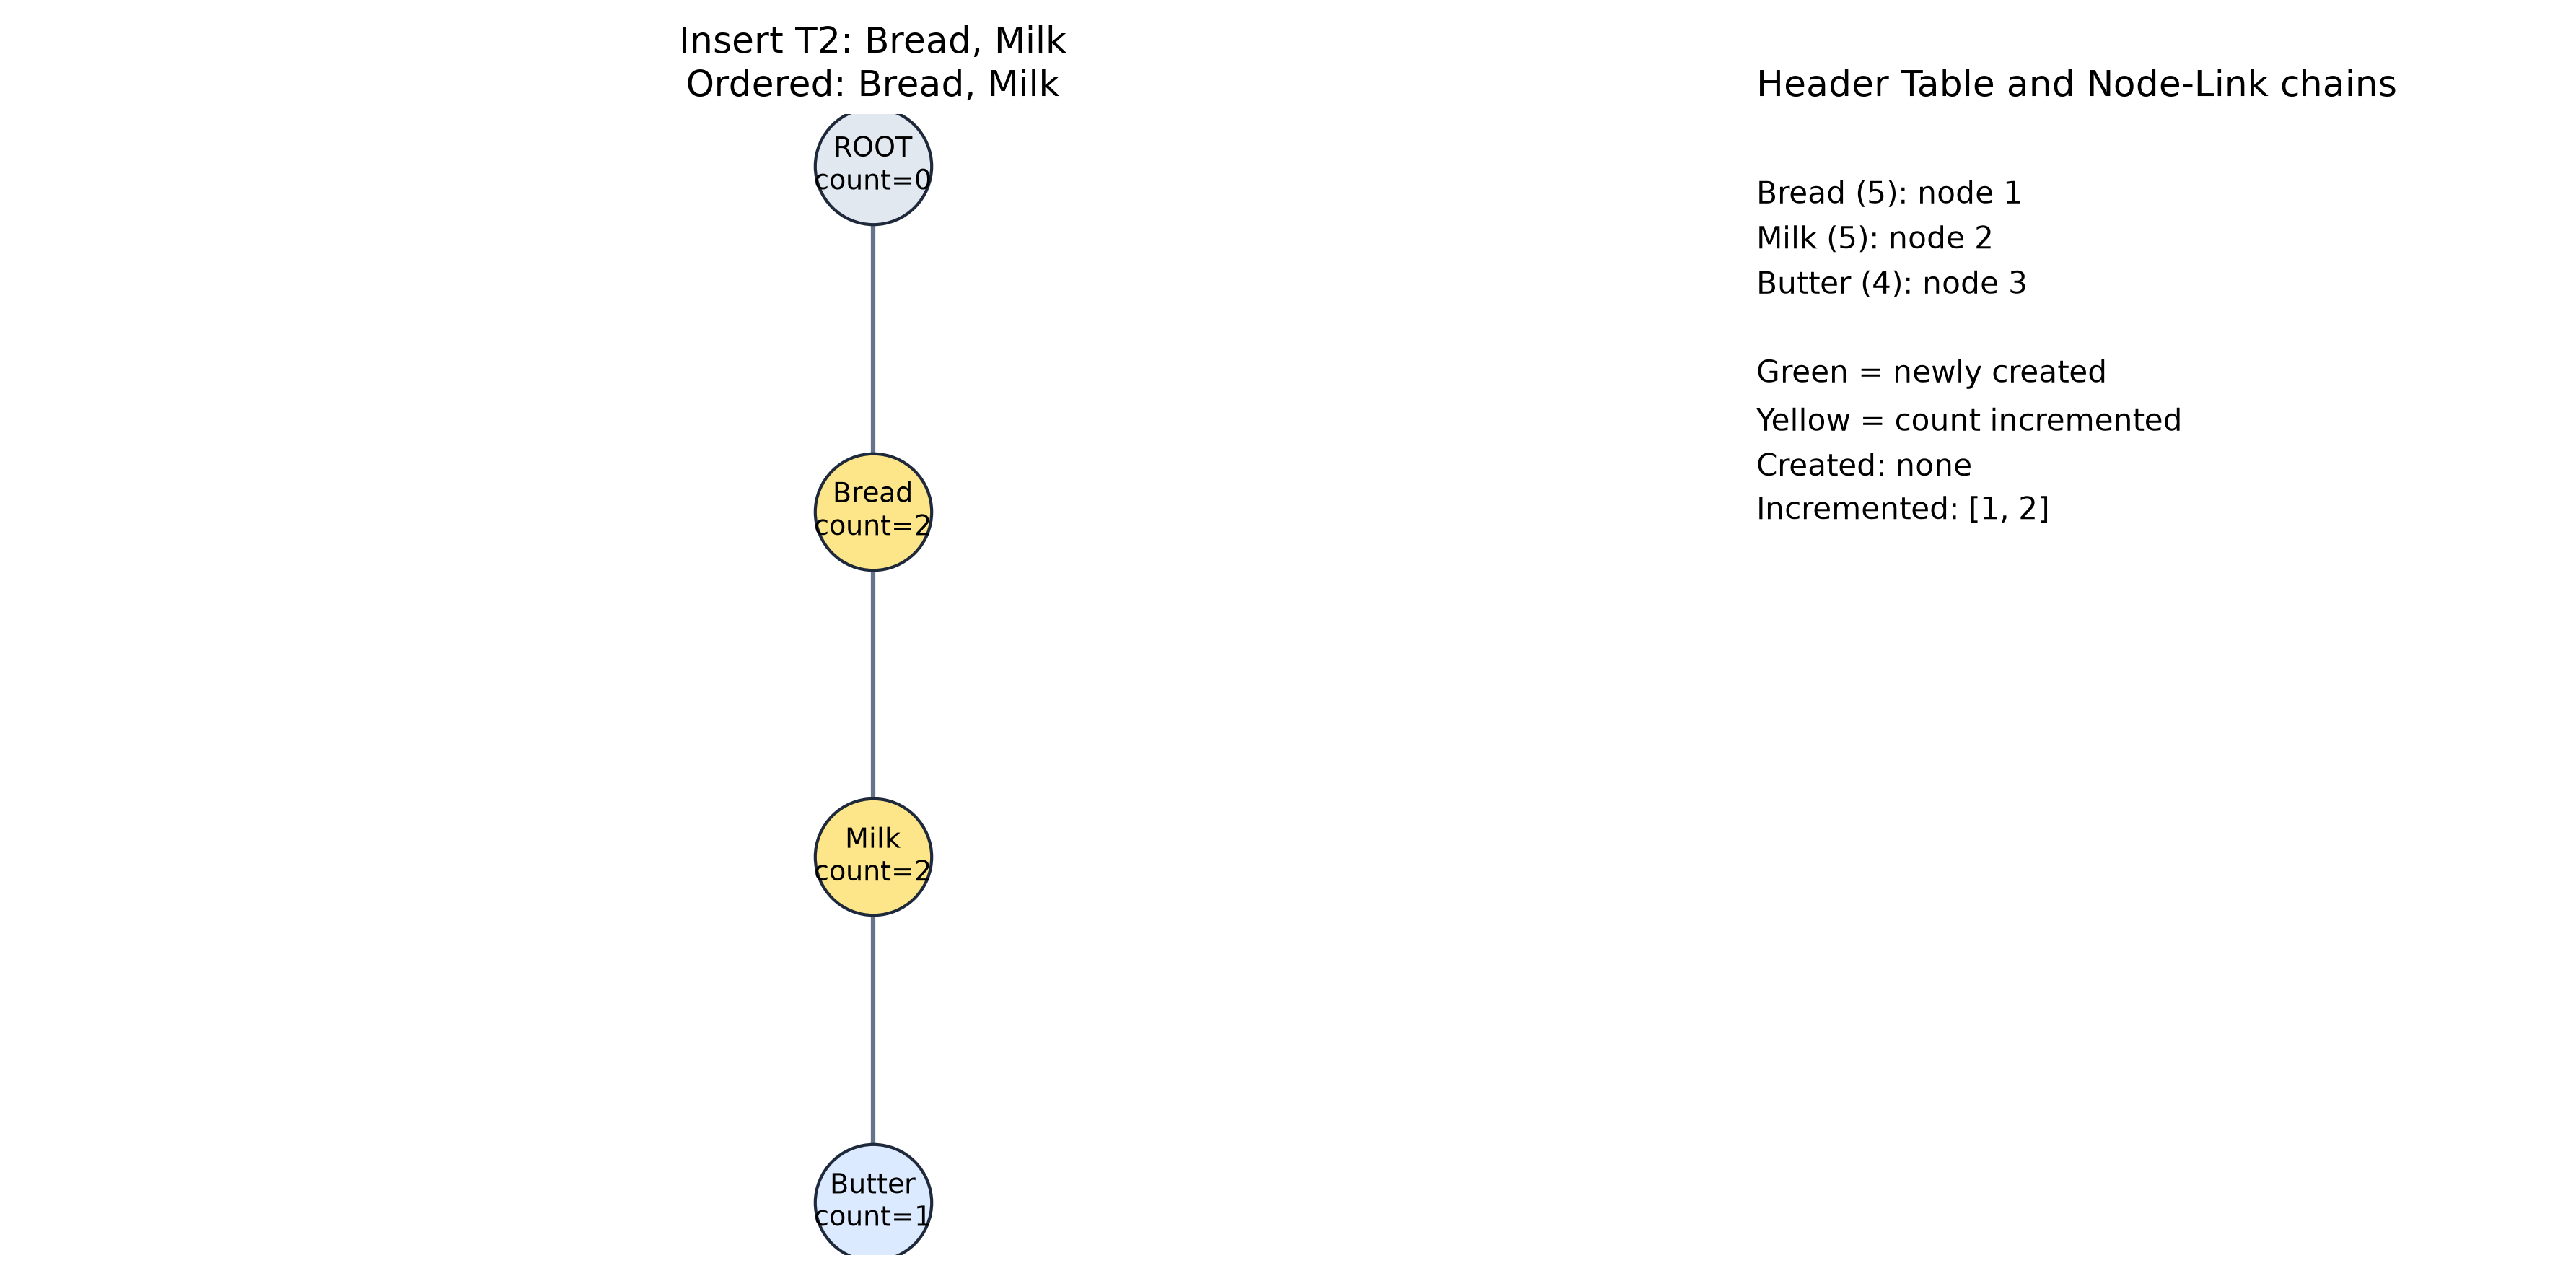

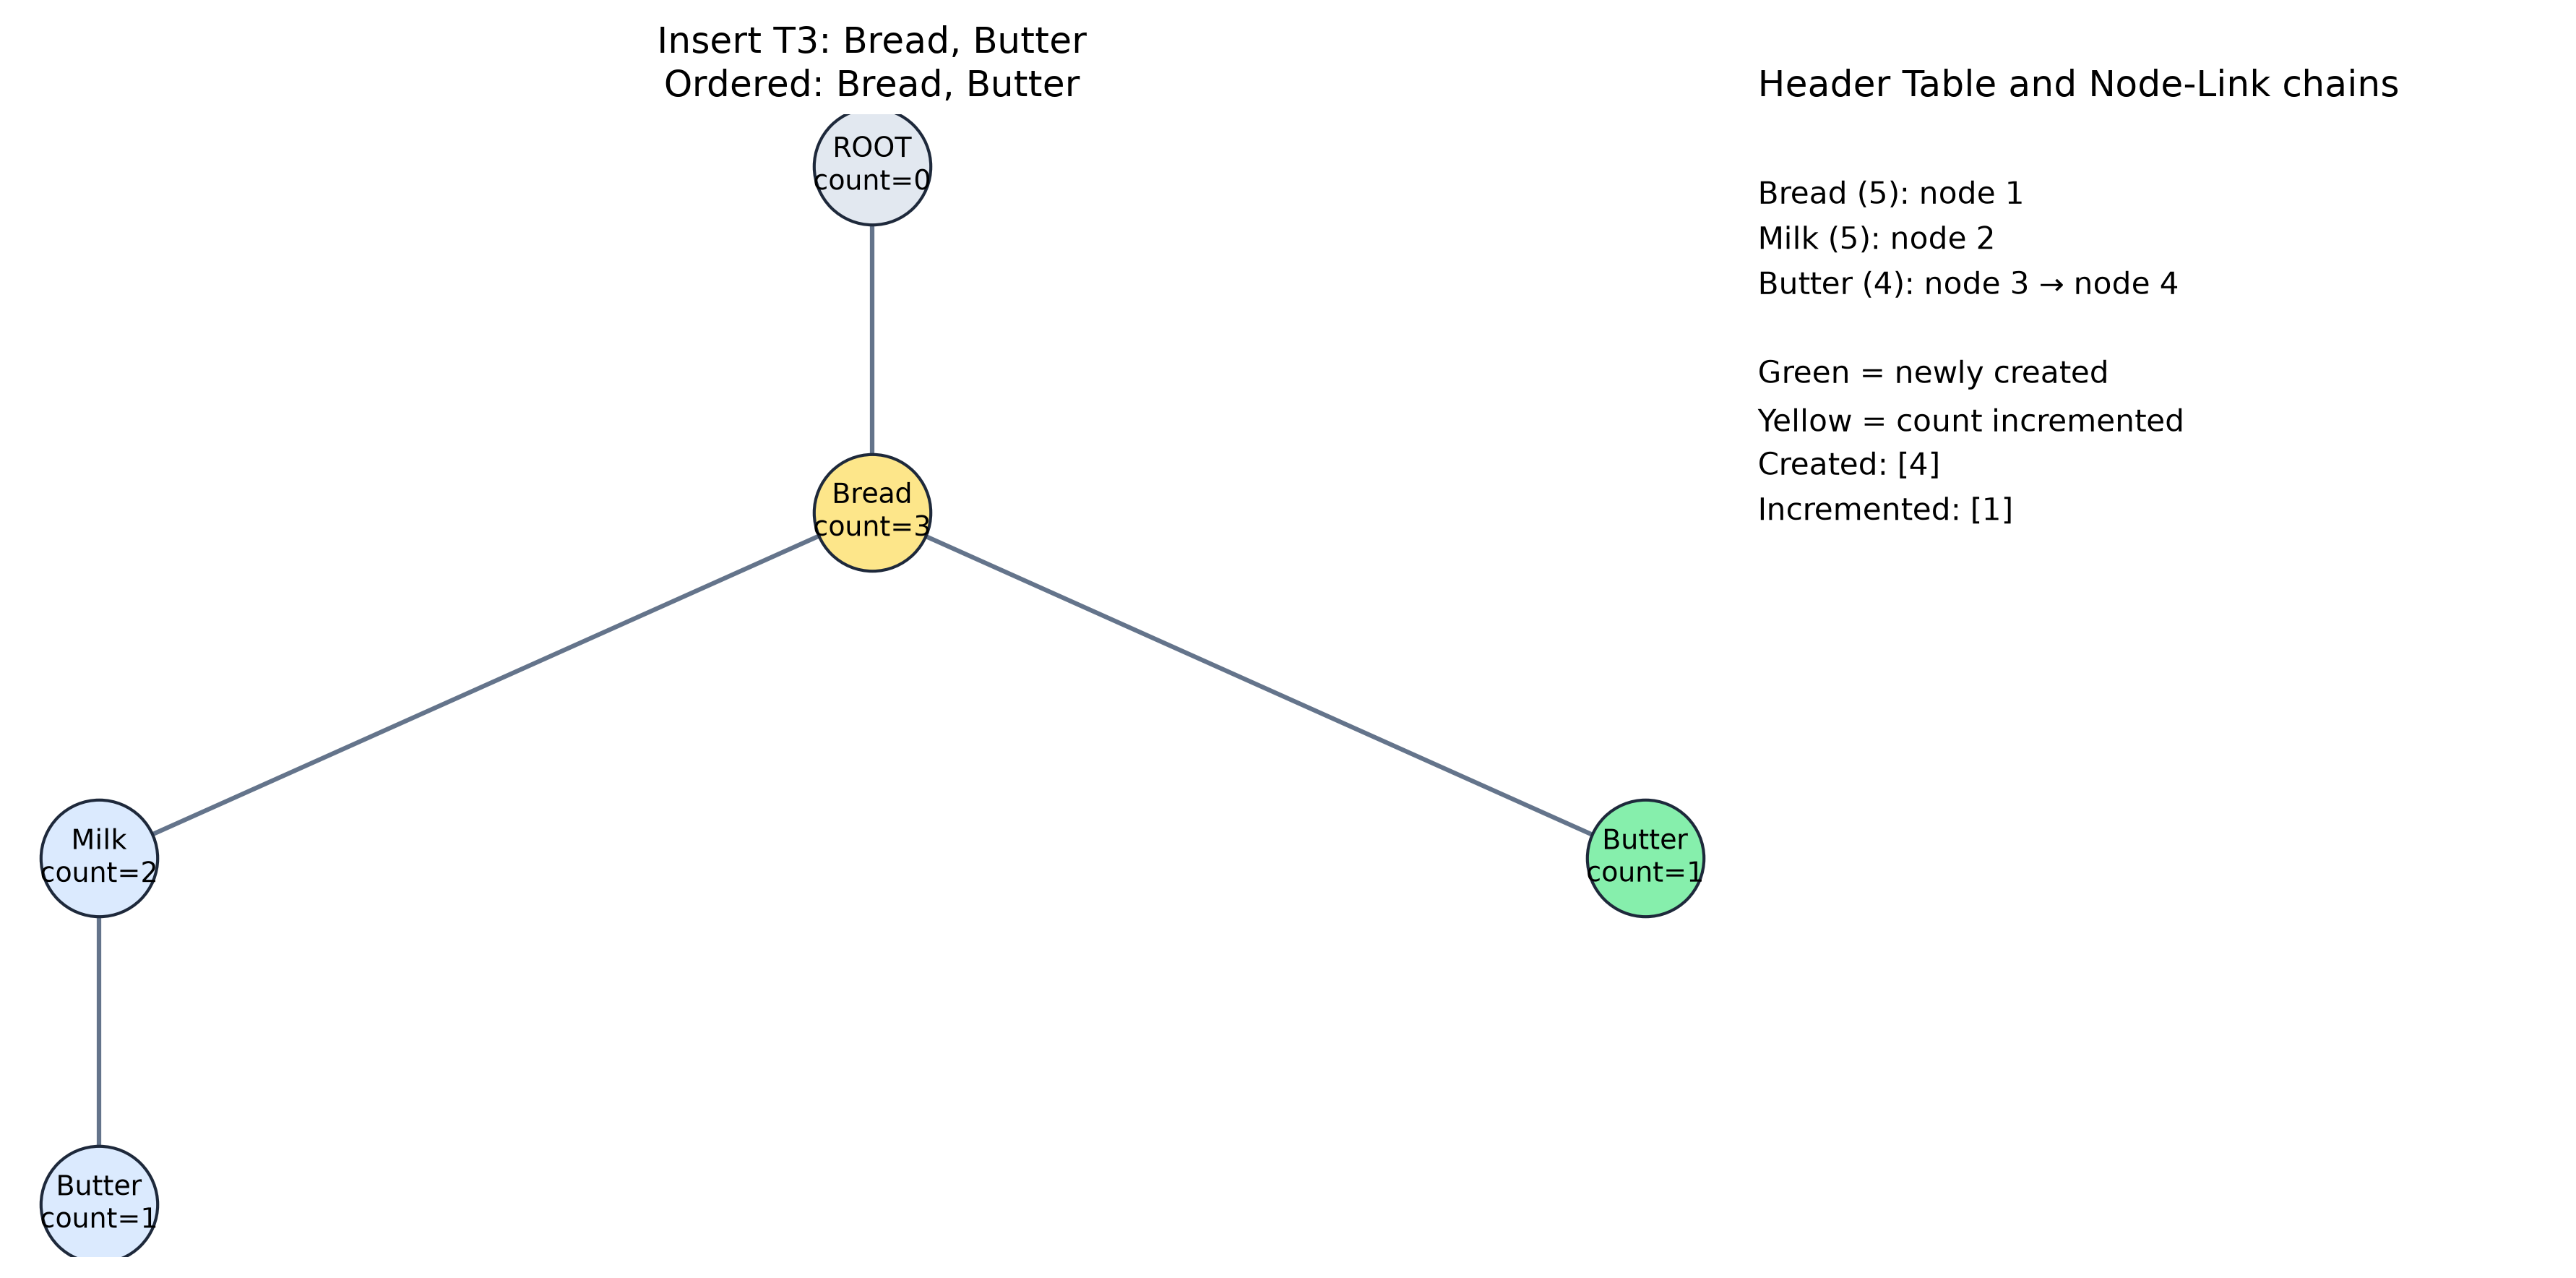

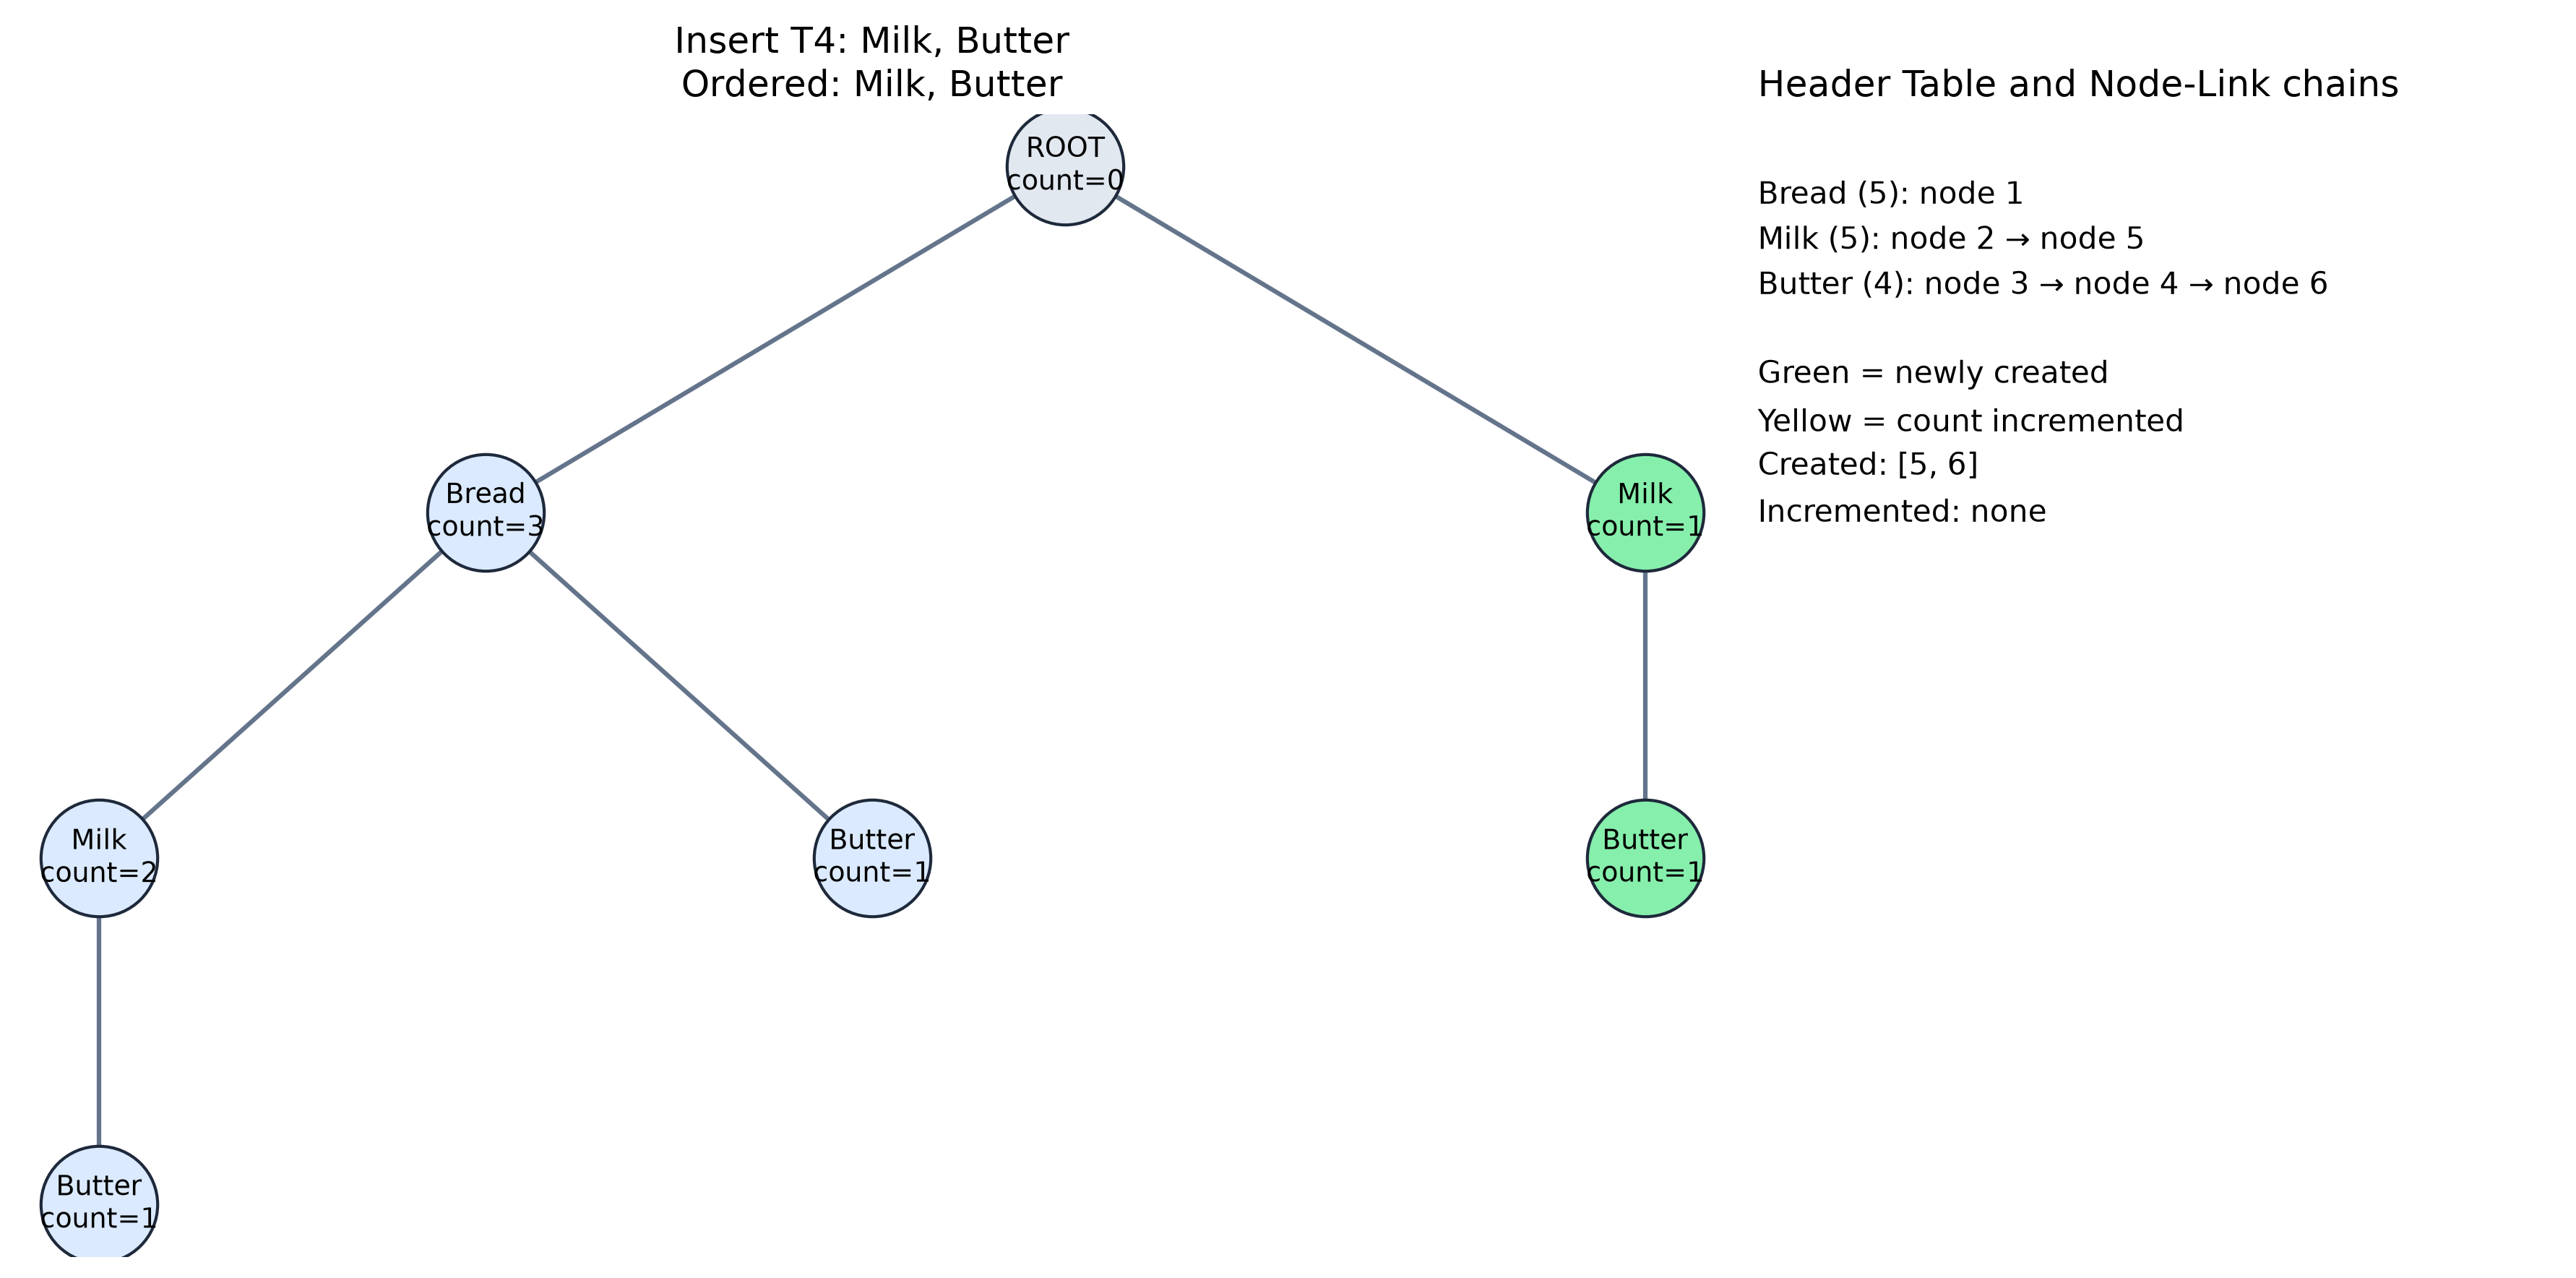

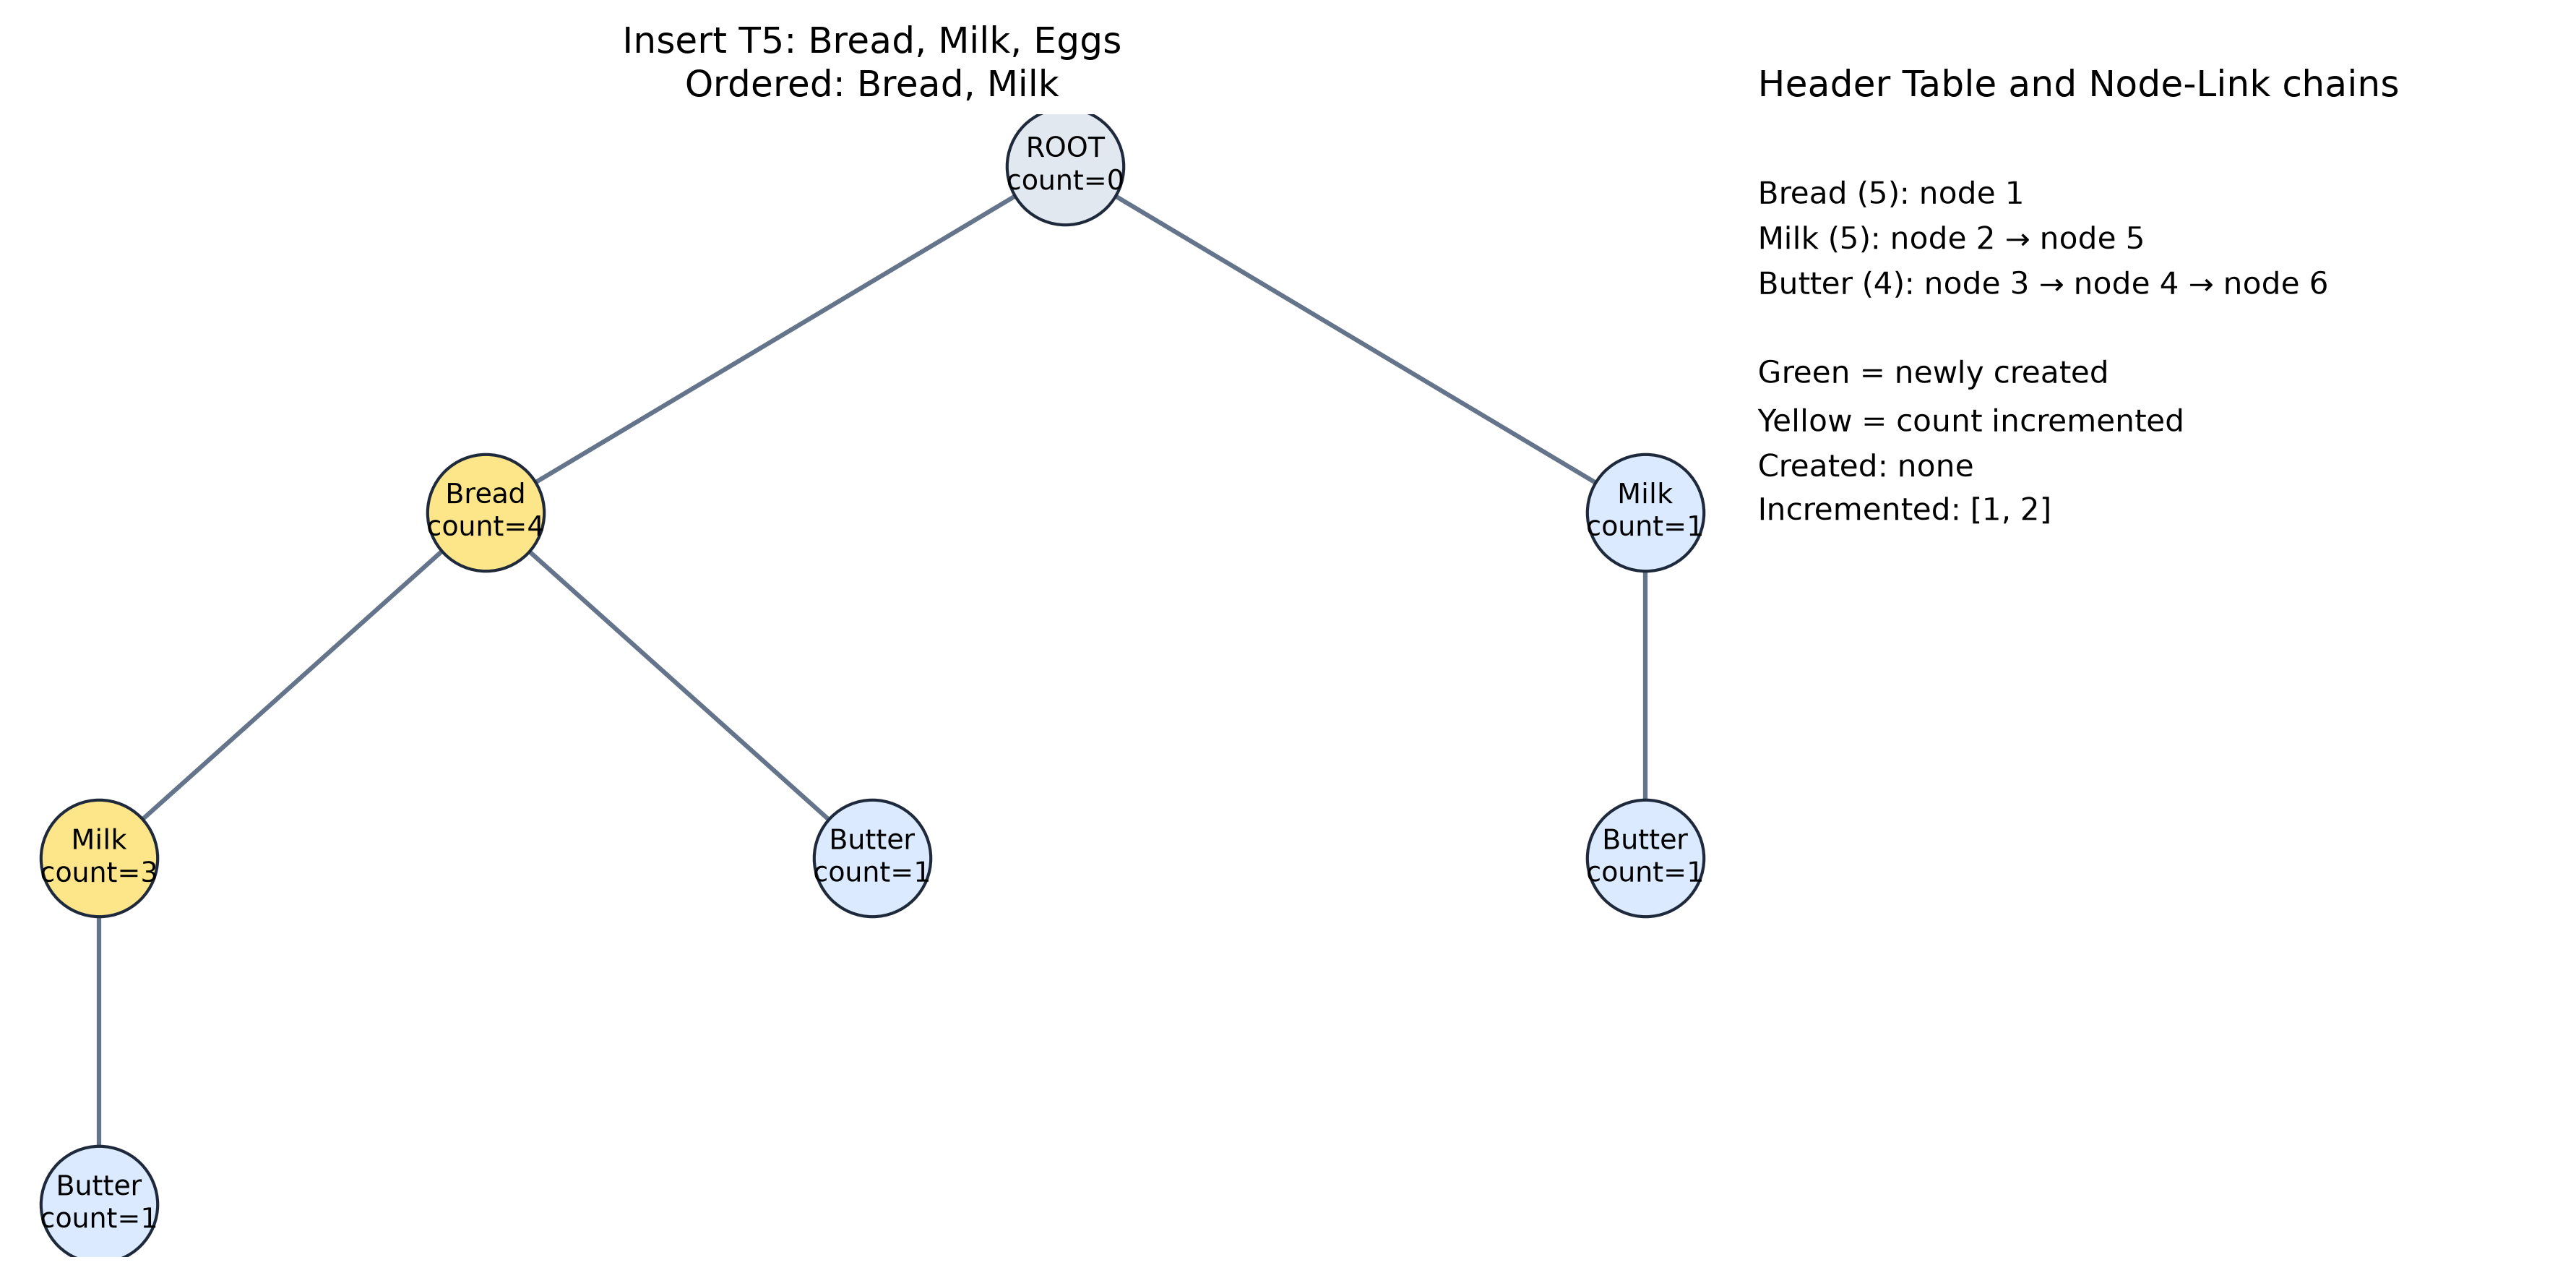

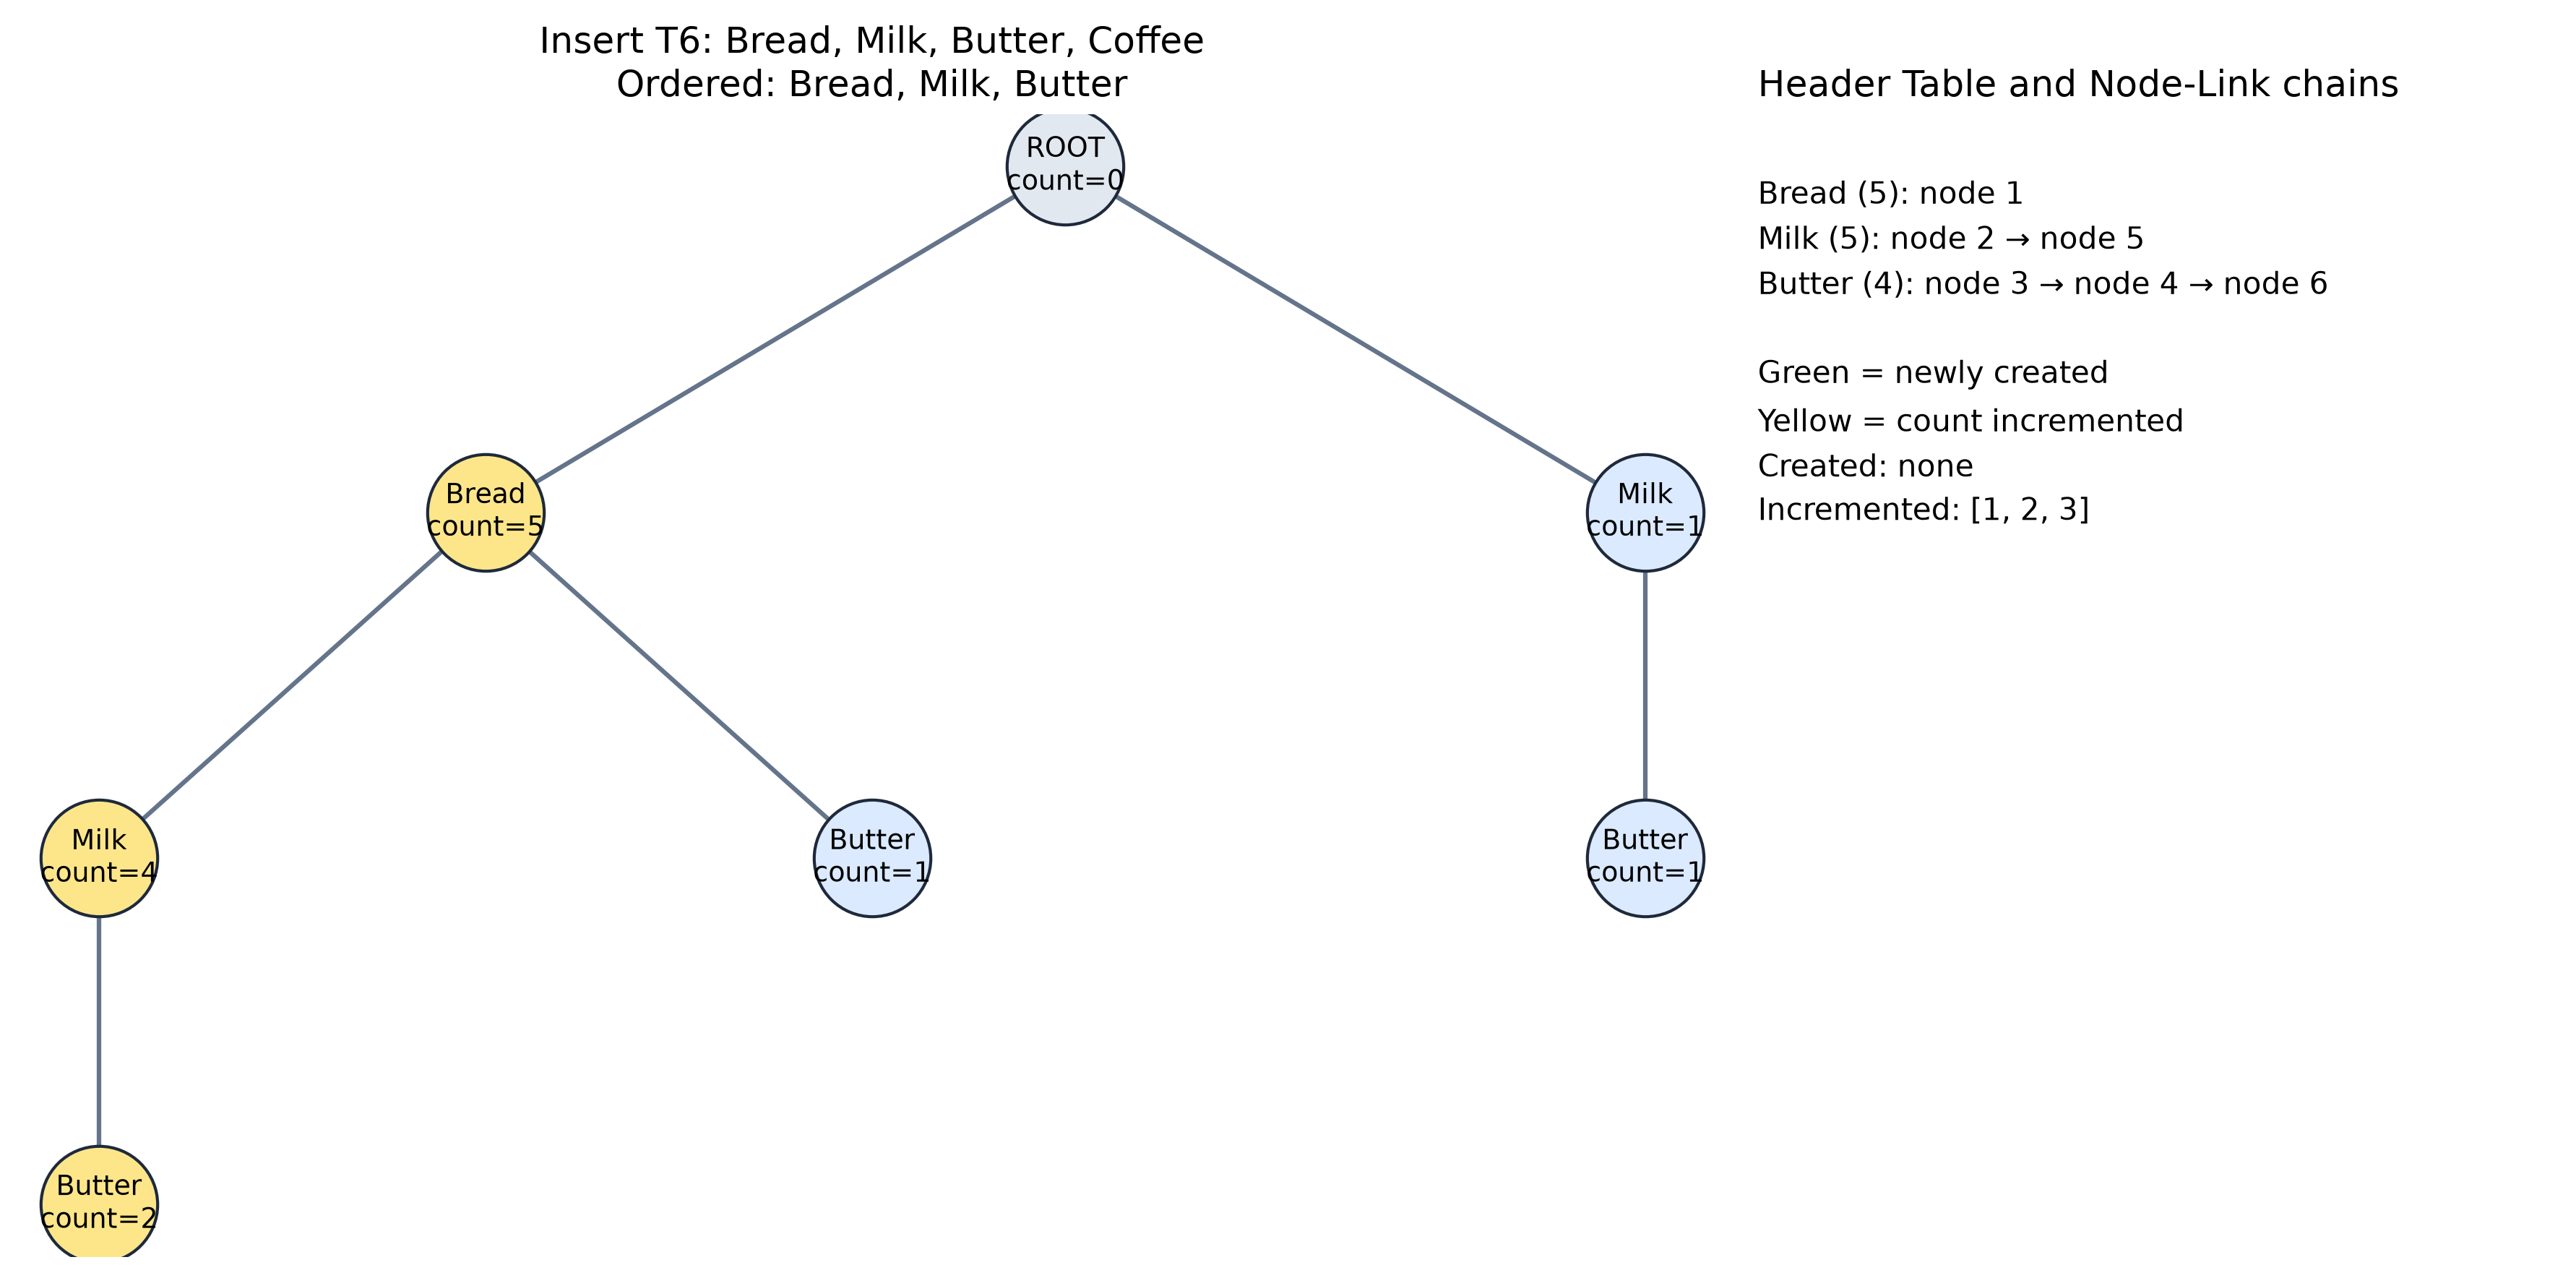

In [3]:
for step in sorted(project_path("outputs", "figures", "manual_fp_tree_steps").glob("step_*.png")):
    display(Image(filename=str(step), width=950))

العقدة الخضراء أُنشئت في الخطوة الحالية، والصفراء زيد عدادها. عندما تدخل T2 بعد T1 لا يُنشأ مسار Bread→Milk جديد، بل يعاد استخدامه وتزداد العدادات. يحتفظ **Header Table** بالدعم الكلي، وتصل **Node-Link** جميع عقد العنصر نفسه عبر الفروع.

## Header Table وNode-Link

In [4]:
header = pd.read_csv(project_path("outputs", "tables", "manual_fp_tree_header_table.csv"))
display(header)
tree, raw_frequencies = build_educational_tree(minimum_support_count=3)
assert [node.count for node in tree.linked_nodes("Butter")] == [2, 1, 1]

,item,support_count,node_link_chain,node_counts
0,Bread,5,1,5
1,Milk,5,2 -> 5,4 -> 1
2,Butter,4,3 -> 4 -> 6,2 -> 1 -> 1


## Conditional Pattern Base وConditional FP-Tree

In [5]:
conditional_bases = pd.read_csv(project_path("outputs", "tables", "manual_fp_tree_conditional_bases.csv"))
display(conditional_bases)
butter_base = tree.conditional_pattern_base("Butter")
butter_conditional_tree = FPTree.build(butter_base, minimum_support_count=3)
print("Butter conditional base:", butter_base)
print("Conditional frequent supports:", butter_conditional_tree.item_supports)

,target_item,prefix_path,path_count
0,Butter,Bread | Milk,2
1,Butter,Bread,1
2,Butter,Milk,1
3,Milk,Bread,4
4,Bread,NaN,0


Butter conditional base: ((('Bread', 'Milk'), 2), (('Bread',), 1), (('Milk',), 1))
Conditional frequent supports: {'Bread': 3, 'Milk': 3}


قاعدة Butter الشرطية هي Bread→Milk بوزن 2، وBread بوزن 1، وMilk بوزن 1. داخل السياق الشرطي يصبح دعم Bread=3 ودعم Milk=3. أما Bread+Milk+Butter فدعمه 2 فقط، لذلك لا يمر بالعتبة 3.

## استخراج Frequent Itemsets والتحقق اليدوي

In [6]:
itemsets = pd.read_csv(project_path("outputs", "tables", "manual_fp_tree_frequent_itemsets.csv"))
display(itemsets)
expected = {
    "Bread": 5, "Butter": 4, "Milk": 5,
    "Bread | Butter": 3, "Bread | Milk": 4, "Butter | Milk": 3,
}
assert dict(zip(itemsets.itemset_key, itemsets.support_count)) == expected
print("Manual verification passed for all six frequent itemsets.")

,itemset_key,itemset_length,support_count,support
0,Bread,1,5,0.833333
1,Butter,1,4,0.666667
2,Milk,1,5,0.833333
3,Bread | Butter,2,3,0.500000
4,Bread | Milk,2,4,0.666667
5,Butter | Milk,2,3,0.500000


Manual verification passed for all six frequent itemsets.


## العارض التفاعلي للخطوات

In [7]:
viewer = Path("outputs") / "interactive" / "manual_fp_tree_steps.html"
assert project_path(*viewer.parts).exists()
display(FileLink(str(viewer), result_html_prefix="Open the self-contained step viewer: "))

D:\University\Data Mining\smartbasket-fpgrowth-lab\outputs\interactive\manual_fp_tree_steps.html

## الفصل عن تحليل البيانات الحقيقية

النتيجة أعلاه خاصة بالمثال التعليمي Bread/Milk/Butter. تحليل UCI الحقيقي موجود في Notebook 04 ويستخدم `mlxtend.fpgrowth` على 17,901 معاملة UK. لا تُنسب أرقام المثال الصغير إلى المتجر الحقيقي.